<a href="https://colab.research.google.com/github/agomesmartins/wine-analysis-ai/blob/main/wine_dataset_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Link to Dataset

https://archive.ics.uci.edu/dataset/186/wine+quality

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

from math import sqrt

# Import Data

####Note:
#####Good Wine Quality > 5
#####Bad Wine Quality <= 5

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
# Visualize Data
print(X.info())
print(X.describe())
print(X.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
dtypes: float64(11)
memory usage: 558.5 KB
None
       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666  

<Axes: >

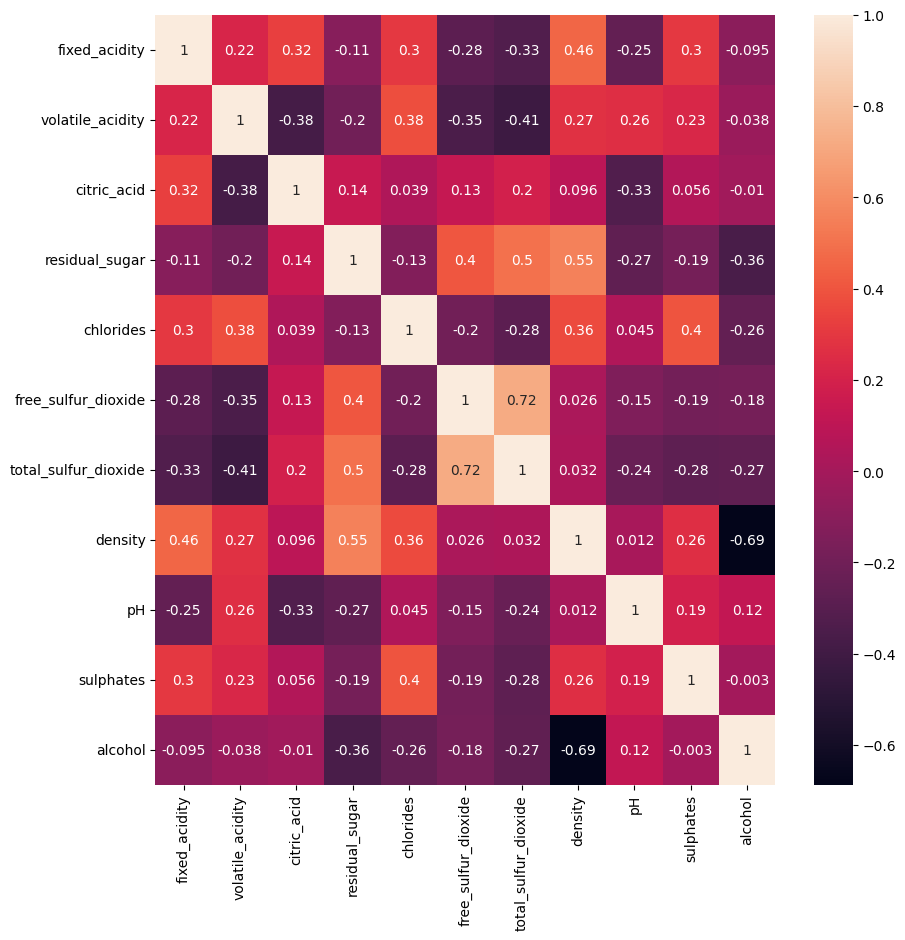

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(X.corr(), annot=True)

In [ ]:
# Change quality to "Good" (1) or "Bad" (0)
y_clean = y['quality'].apply(lambda x: 1 if x > 5 else 0)


In [ ]:
# Split Dataset
# Dataset Has 6497 datapoints, Use 30% to test (Still have more than 750 to train)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_clean, test_size=0.3)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4547, 11)
(1950, 11)
(4547,)
(1950,)


# Methods Used



*   Python Function To time the code running
*   Confusion Matrix



## Method 1: FLD / Linear Regression

In [ ]:
# Import Library
from sklearn.linear_model import LinearRegression

# Build
start_1 = time.perf_counter() # Start Timer

regressor = LinearRegression(fit_intercept =True)
regressor.fit(X_train,y_train)

end_1 = time.perf_counter() # End Timer

# Print Coefficients
print('Linear Model Coefficient (m): ', regressor.coef_)
print('Linear Model Coefficient (b): ', regressor.intercept_)

train_time_1 = end_1 - start_1
# Print Time
print(f"Elapsed time: {end_1 - start_1:.4f} seconds")

Linear Model Coefficient (m):  [ 1.84958449e-02 -8.68270561e-01 -1.31105308e-01  1.61842762e-02
 -3.18258474e-01  2.97214556e-03 -1.41560668e-03 -1.00400538e+01
  1.69105560e-01  3.30810870e-01  1.46901405e-01]
Linear Model Coefficient (b):  8.557550832033309
Elapsed time: 0.0052 seconds


In [ ]:
# Testing
start_1_test = time.perf_counter() # Start Timer
y_predict_1 = regressor.predict(X_test)

end_1_test = time.perf_counter() # End Timer

test_time_1 = end_1_test - start_1_test
# Evaluate
print(classification_report(y_test, y_predict_1.round(0)))

              precision    recall  f1-score   support

           0       0.65      0.56      0.60       670
           1       0.79      0.84      0.81      1280

    accuracy                           0.75      1950
   macro avg       0.72      0.70      0.71      1950
weighted avg       0.74      0.75      0.74      1950



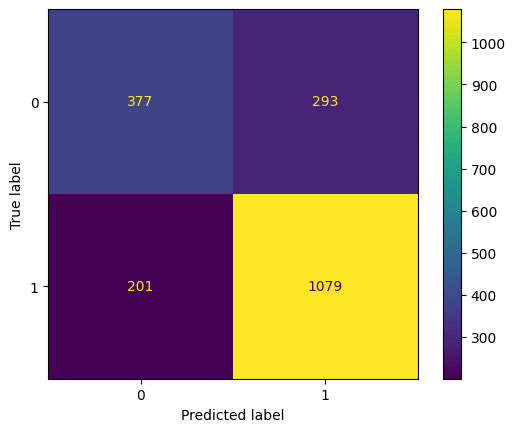

True Negative: 377, False Positive: 293, False Negative: 201, True Positive: 1079


<Axes: >

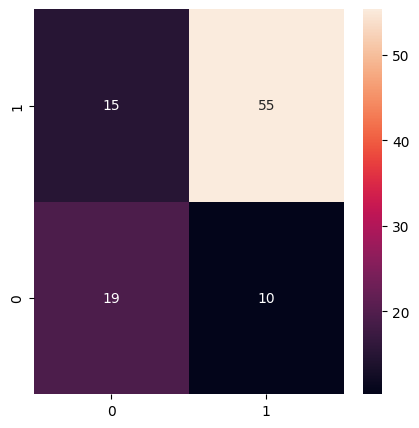

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_predict_1.round(0))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#Plot Percentages as Specified in Assignment
tn, fp, fn, tp = confusion_matrix(y_test, y_predict_1.round(0)).ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
net_test = tn + fp + fn + tp
array = [[fp/net_test*100, tp/net_test*100],[tn/net_test*100,fn/net_test*100]]
df_cm = pd.DataFrame(array, index = [i for i in "10"],
                  columns = [i for i in "01"])
plt.figure(figsize = (5,5))
sns.heatmap(df_cm, annot=True)

## Method 2: Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

start_2 = time.perf_counter() # Start Timer

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

end_2 = time.perf_counter() # End Timer

train_time_2 = end_2 - start_2
# Print Time
print(f"Elapsed time: {end_2 - start_2:.4f} seconds")

Elapsed time: 1.0772 seconds


In [ ]:
start_2_test = time.perf_counter() # Start Timer

y_predict_2 = model_rf.predict(X_test)

end_2_test = time.perf_counter() # End Timer

test_time_2 = end_2_test - start_2_test

# Evaluate
print(classification_report(y_test, y_predict_2))

              precision    recall  f1-score   support

           0       0.78      0.72      0.75       670
           1       0.86      0.89      0.88      1280

    accuracy                           0.83      1950
   macro avg       0.82      0.81      0.81      1950
weighted avg       0.83      0.83      0.83      1950



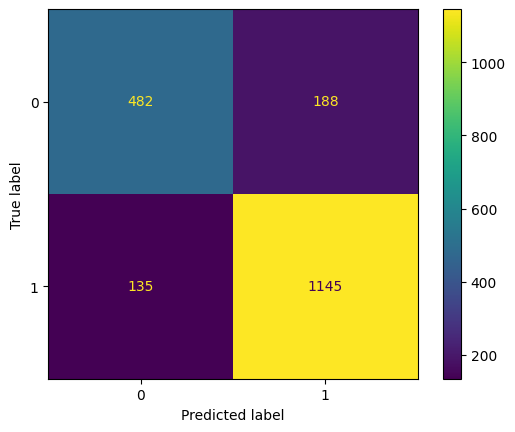

True Negative: 482, False Positive: 188, False Negative: 135, True Positive: 1145


<Axes: >

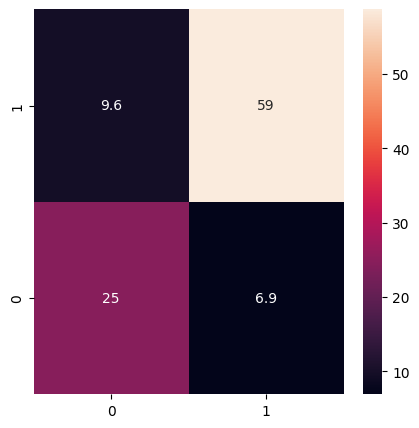

In [ ]:
cm = confusion_matrix(y_test, y_predict_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
# FIX MATRIX

#Plot Percentages as Specified in Assignment
tn, fp, fn, tp = confusion_matrix(y_test, y_predict_2).ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
net_test = tn + fp + fn + tp
array = [[fp/net_test*100, tp/net_test*100],[tn/net_test*100,fn/net_test*100]]
df_cm = pd.DataFrame(array, index = [i for i in "10"],
                  columns = [i for i in "01"])
plt.figure(figsize = (5,5))
sns.heatmap(df_cm, annot=True)

# Show Relivant Data

In [ ]:
# Print Times For Method 1
print(f"Training time Method 1: {train_time_1:.4f} seconds")
print(f"Testing time Method 1: {test_time_1:.4f} seconds")
# Print Times For Method 2
print(f"Training time Method 2: {train_time_2:.4f} seconds")
print(f"Testing time Method 2: {test_time_2:.4f} seconds")

Training time Method 1: 0.0052 seconds
Testing time Method 1: 0.0041 seconds
Training time Method 2: 1.0772 seconds
Testing time Method 2: 0.0429 seconds
